In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

## create the connection and upload data

In [2]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [45]:
checker_table = pd.read_sql(
    '''
SELECT uid, numTrials, timestamp
FROM checker
WHERE uid LIKE 'user_%' AND labname = 'project1' AND status = 'ready'
ORDER BY timestamp
''', conn, parse_dates='timestamp'
)
checker_table

,uid,numTrials,timestamp
0,user_4,1,2020-04-17 05:19:02.744528
1,user_4,2,2020-04-17 05:22:45.549397
2,user_4,3,2020-04-17 05:34:24.422370
3,user_4,4,2020-04-17 05:43:27.773992
4,user_4,5,2020-04-17 05:46:32.275104
...,...,...,...
946,user_19,26,2020-05-15 10:22:39.698523
947,user_19,27,2020-05-15 10:22:46.248162
948,user_19,28,2020-05-15 10:23:18.043212
949,user_28,27,2020-05-15 10:38:14.430013


## make a graph

Text(0.5, 0.98, 'Dynamic of commits per user in project1')

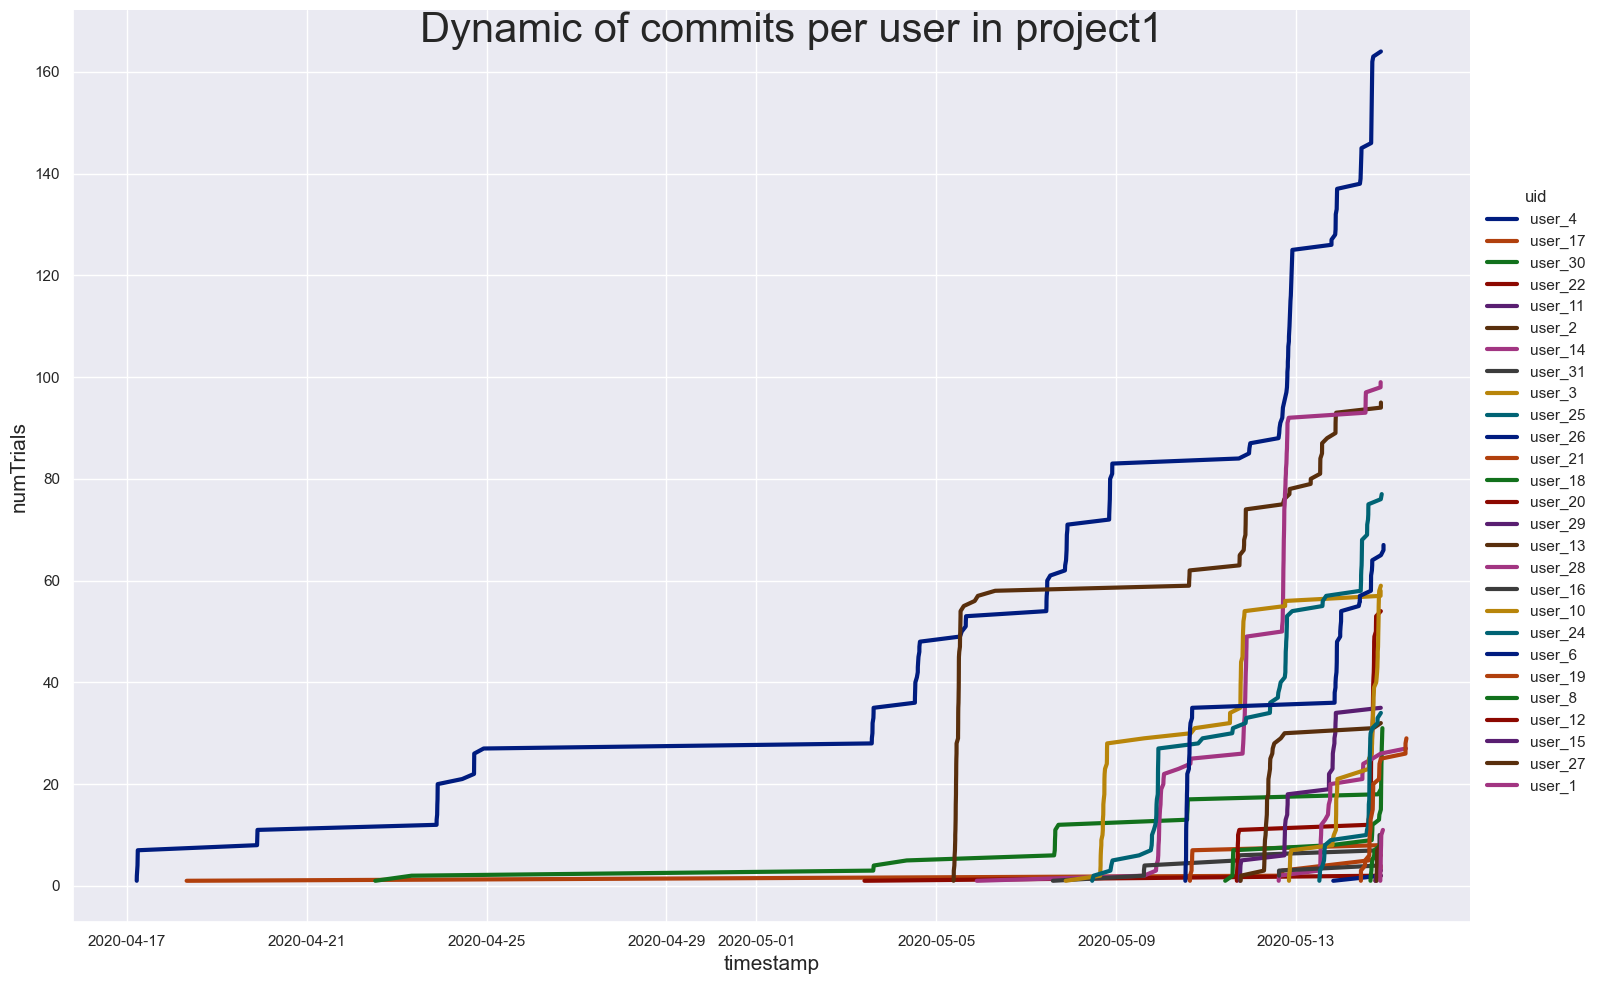

In [71]:
sns.set_theme(palette='grey',
              rc={'axes.labelsize' : 15,
                  'lines.linewidth' : 3})
sns.relplot(data=checker_table,
            x='timestamp',
            y='numTrials',
            hue='uid',
            legend='full',
            kind='line',
            height=10,
            aspect=1.5,
            palette='dark')
plt.suptitle('Dynamic of commits per user in project1', fontsize=30)

In [61]:
conn.close()

## Which user was the leader in the number of commits almost all of the time? - user_4

## Which user was the leader for only a short period of time? - user_2